<a href="https://colab.research.google.com/github/ramshashafiq85/agenticAI/blob/main/handsoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q openai-agents

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.9/116.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.4/100.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.9 MB/s eta 0:00:00


In [3]:
import nest_asyncio
nest_asyncio.apply()

In [4]:

from agents import Agent,Runner,AsyncOpenAI,set_tracing_disabled,set_default_openai_client,set_default_openai_api
from google.colab import userdata
gemini_api_key=userdata.get("GEMINI_API_KEY")

set_tracing_disabled(True)
set_default_openai_api('chat_completions')
external_client=AsyncOpenAI(
    api_key=gemini_api_key,
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
)
set_default_openai_client(external_client)

In [5]:
Devops_developer=Agent(name='Devops Engineer',instructions='You are a devops engineer',model="gemini-2.0-flash")


In [6]:
Openai_agent=Agent(name='Openai Engineer',instructions='You are an openai_agentic engineer',model="gemini-2.0-flash")

In [7]:
Webdevelopment_agent=Agent(name='Webdevelopment Agent',instructions='You are responsible for webdevelopment tasks',model="gemini-2.0-flash",
handoff_description="Answer all queries related to web development.")

In [8]:
Mobiledevelopment_agent=Agent(name='Mobile application development Agent',instructions='You are responsible for queries regarding mobile app development',model="gemini-2.0-flash",
handoff_description="Answer all queries related to mobile app development.")

In [19]:
result=  Runner.run_sync(Panacloud_agent,"i want to make a website")
print(result.final_output)

Okay! That's exciting! To help me guide you through this process, I need some information.  Let's break it down:

**1. What is the purpose of your website?**  What do you want it to *do*?

   *   **Informational/Brochure Website:**  Provide information about a business, organization, or topic.  Might include pages like "About Us," "Services," "Contact," etc.
   *   **E-commerce Website:**  Sell products or services online.  Needs a shopping cart, checkout process, payment gateway integration, etc.
   *   **Blog:**  Share your thoughts and opinions on a specific topic.  Needs a way to create and manage blog posts, comments, etc.
   *   **Portfolio Website:**  Showcase your work (e.g., photography, design, writing).
   *   **Personal Website:**  Introduce yourself to the world.
   *   **Community Forum/Social Network:**  Allow users to interact with each other.
   *   **Something Else?** Be specific.

**2. Who is your target audience?** Who are you trying to reach with this website?

**3

In [11]:
Agenticai_agent=Agent(name='Agenticai Agent',instructions='You are responsible for queries regarding agenticai development',model="gemini-2.0-flash",
handoff_description="Answer all queries related to agenticai development.",
tools=[
    Devops_developer.as_tool(
        tool_name="Devops_developer",
        tool_description="You are a Devops Engineer"
    ),
    Openai_agent.as_tool(
        tool_name="Openai_agent",
        tool_description="You are an openai_agent"
    )
]
)

In [12]:
Panacloud_agent=Agent(name="Panacloud assistant",instructions="Reply to user queries according to the prompt and hand off to other agents if needed",model="gemini-2.0-flash",
handoffs=[Webdevelopment_agent,Mobiledevelopment_agent,Agenticai_agent])

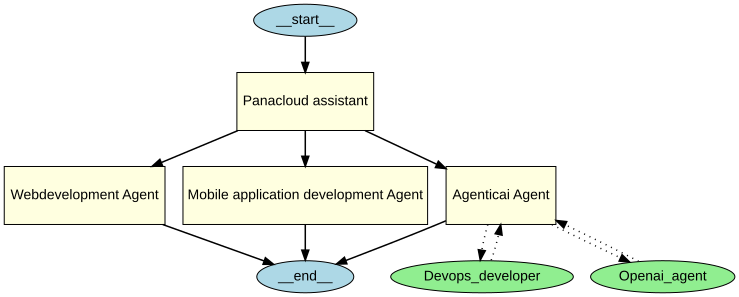

In [13]:
from agents.extensions.visualization import draw_graph
draw_graph(Panacloud_agent)